# Notebook 16 — Literature comparison

Compares this project's four models (`model_comparison_metrics.csv`, from notebook 15) against two published citrus-disease studies. No training or inference here, just reading existing results and lining them up against numbers taken directly from the published papers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## This project's results

In [2]:
project_df = pd.read_csv('model_comparison_metrics.csv')
project_df

,architecture,test_accuracy,macro_precision,macro_recall_sensitivity,macro_specificity,macro_f1,mean_roc_auc,param_count,model_size_mb,mean_inference_latency_ms,throughput_images_per_sec
0,resnet50,0.995833,0.995192,0.996094,0.998677,0.995604,1.000000,23770820,90.678482,8.082305,123.727080
1,densenet121,0.987500,0.988401,0.988401,0.995731,0.988372,0.999558,7085572,27.029312,21.273749,47.006289
2,citrusnet,0.966667,0.965749,0.969171,0.989117,0.966375,0.997139,416036,1.587051,2.701898,370.110197
3,efficientnet_b0,0.929167,0.943336,0.933834,0.976349,0.932485,0.989402,4172032,15.915039,18.068612,55.344594


## Study A — Goyal & Lakhwani (2025) [3]

759 images across 9 classes (5 fruit disease categories, 5 leaf categories), 70/15/15 split. Two-phase transfer learning, but phase 2 only unfreezes the last 20 layers rather than the full network.

In [3]:
study_a_df = pd.DataFrame([
    {'study': 'Study A [3]', 'architecture': 'EfficientNetB0', 'test_accuracy': 80.18, 'macro_f1': 0.445, 'dataset_images': 759, 'dataset_classes': 9, 'fine_tuning_strategy': 'partial-20-layers'},
    {'study': 'Study A [3]', 'architecture': 'ResNet50', 'test_accuracy': 84.58, 'macro_f1': 0.649, 'dataset_images': 759, 'dataset_classes': 9, 'fine_tuning_strategy': 'partial-20-layers'},
    {'study': 'Study A [3]', 'architecture': 'DenseNet121', 'test_accuracy': 99.12, 'macro_f1': 0.986, 'dataset_images': 759, 'dataset_classes': 9, 'fine_tuning_strategy': 'partial-20-layers'},
    {'study': 'Study A [3]', 'architecture': 'InceptionV3', 'test_accuracy': 99.12, 'macro_f1': 0.986, 'dataset_images': 759, 'dataset_classes': 9, 'fine_tuning_strategy': 'partial-20-layers'},
])
study_a_df

,study,architecture,test_accuracy,macro_f1,dataset_images,dataset_classes,fine_tuning_strategy
0,Study A [3],EfficientNetB0,80.18,0.445,759,9,partial-20-layers
1,Study A [3],ResNet50,84.58,0.649,759,9,partial-20-layers
2,Study A [3],DenseNet121,99.12,0.986,759,9,partial-20-layers
3,Study A [3],InceptionV3,99.12,0.986,759,9,partial-20-layers


## Study B — Goyal et al. (2026) [4]

~180 field-collected images from Abohar, Punjab, plus public GitHub/Kaggle images used for external validation. 4 classes (blackspot, canker, dieback, healthy) — a different taxonomy from this project's own four classes. AgriVision-L5 is their proposed model: a custom 5-conv-layer CNN with global average pooling before the classifier, similar in spirit to CitrusNet.

In [4]:
study_b_df = pd.DataFrame([
    {'study': 'Study B [4]', 'architecture': 'AgriVision-L5', 'test_accuracy': 92.59, 'macro_f1': 0.9744, 'dataset_images': '~180 + external', 'dataset_classes': 4, 'fine_tuning_strategy': 'from-scratch', 'model_size_mb': 0.79},
    {'study': 'Study B [4]', 'architecture': 'InceptionV3', 'test_accuracy': 92.59, 'macro_f1': np.nan, 'dataset_images': '~180 + external', 'dataset_classes': 4, 'fine_tuning_strategy': 'frozen-entirely', 'model_size_mb': 155.05},
    {'study': 'Study B [4]', 'architecture': 'MobileNetV2', 'test_accuracy': 92.59, 'macro_f1': np.nan, 'dataset_images': '~180 + external', 'dataset_classes': 4, 'fine_tuning_strategy': 'frozen-entirely', 'model_size_mb': 69.87},
])
study_b_df

,study,architecture,test_accuracy,macro_f1,dataset_images,dataset_classes,fine_tuning_strategy,model_size_mb
0,Study B [4],AgriVision-L5,92.59,0.9744,~180 + external,4,from-scratch,0.79
1,Study B [4],InceptionV3,92.59,NaN,~180 + external,4,frozen-entirely,155.05
2,Study B [4],MobileNetV2,92.59,NaN,~180 + external,4,frozen-entirely,69.87


## A note on comparability

These are not apples-to-apples numbers. Study A's 759 images span 9 classes across both fruit and leaf symptoms; Study B's ~180 field images use a 4-class taxonomy (blackspot/canker/dieback/healthy) that doesn't match this project's own (aphids/gummosis/healthy/leaf miner). Dataset size, class taxonomy, and disease type all differ from this project's own dataset. The accuracy percentages below shouldn't be read as directly equivalent — the value here is in the methodological and architectural patterns, not in treating the numbers as a leaderboard.

## Combined comparison table

In [5]:
# test_accuracy in this project's own CSV may be stored as a 0-1 fraction rather than
# a percentage depending on how notebook 15 saved it -- normalize defensively.
def to_percent(x):
    return x * 100 if pd.notna(x) and x <= 1 else x

ft_strategy_map = {
    'citrusnet': 'from-scratch',
    'resnet50': 'full network',
    'efficientnet_b0': 'full network',
    'densenet121': 'full network',
}
arch_display_map = {
    'citrusnet': 'CitrusNet',
    'resnet50': 'ResNet50',
    'efficientnet_b0': 'EfficientNetB0',
    'densenet121': 'DenseNet121',
}

this_project_rows = []
for _, row in project_df.iterrows():
    key = str(row['architecture']).lower()
    this_project_rows.append({
        'source': 'This project',
        'architecture': arch_display_map.get(key, row['architecture']),
        'test_accuracy': to_percent(row['test_accuracy']),
        'macro_f1': row['macro_f1'],
        'fine_tuning_strategy': ft_strategy_map.get(key, 'full network'),
        'notes': '',
    })
this_project_df = pd.DataFrame(this_project_rows)

study_a_combined = study_a_df.rename(columns={'study': 'source'})[['source', 'architecture', 'test_accuracy', 'macro_f1', 'fine_tuning_strategy']].copy()
study_a_combined['notes'] = '759 img, 9-class dataset (fruit + leaf)'

study_b_combined = study_b_df.rename(columns={'study': 'source'})[['source', 'architecture', 'test_accuracy', 'macro_f1', 'fine_tuning_strategy']].copy()
study_b_combined['notes'] = '~180 field img, 4-class (different taxonomy)'

combined_df = pd.concat([this_project_df, study_a_combined, study_b_combined], ignore_index=True)

source_order = ['This project', 'Study A [3]', 'Study B [4]']
combined_df['source'] = pd.Categorical(combined_df['source'], categories=source_order, ordered=True)
combined_df = combined_df.sort_values(['source', 'test_accuracy'], ascending=[True, False]).reset_index(drop=True)

combined_df.to_csv('literature_comparison_table.csv', index=False)
combined_df

,source,architecture,test_accuracy,macro_f1,fine_tuning_strategy,notes
0,This project,ResNet50,99.583333,0.995604,full network,
1,This project,DenseNet121,98.750000,0.988372,full network,
2,This project,CitrusNet,96.666667,0.966375,from-scratch,
3,This project,EfficientNetB0,92.916667,0.932485,full network,
4,Study A [3],DenseNet121,99.120000,0.986000,partial-20-layers,"759 img, 9-class dataset (fruit + leaf)"
5,Study A [3],InceptionV3,99.120000,0.986000,partial-20-layers,"759 img, 9-class dataset (fruit + leaf)"
6,Study A [3],ResNet50,84.580000,0.649000,partial-20-layers,"759 img, 9-class dataset (fruit + leaf)"
7,Study A [3],EfficientNetB0,80.180000,0.445000,partial-20-layers,"759 img, 9-class dataset (fruit + leaf)"
8,Study B [4],AgriVision-L5,92.590000,0.974400,from-scratch,"~180 field img, 4-class (different taxonomy)"
9,Study B [4],InceptionV3,92.590000,NaN,frozen-entirely,"~180 field img, 4-class (different taxonomy)"


## Same architecture, across sources

Only architecture families that show up in at least two of the three sources are plotted. "Custom CNN" groups CitrusNet and AgriVision-L5 together -- they aren't the same architecture, but both are small from-scratch CNNs built for the same purpose (see the note below).

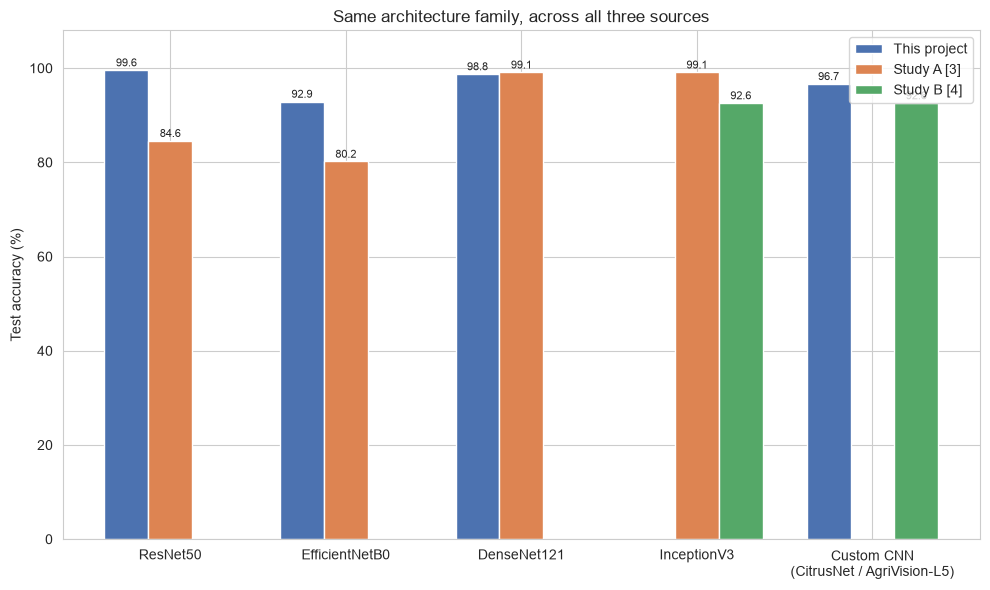

In [6]:
def get_acc(source, architecture):
    row = combined_df[(combined_df['source'] == source) & (combined_df['architecture'] == architecture)]
    return row['test_accuracy'].iloc[0] if len(row) else np.nan

families_order = ['ResNet50', 'EfficientNetB0', 'DenseNet121', 'InceptionV3', 'Custom CNN\n(CitrusNet / AgriVision-L5)']
sources_order = ['This project', 'Study A [3]', 'Study B [4]']

heights = {
    'This project': [get_acc('This project', 'ResNet50'), get_acc('This project', 'EfficientNetB0'),
                      get_acc('This project', 'DenseNet121'), np.nan, get_acc('This project', 'CitrusNet')],
    'Study A [3]': [get_acc('Study A [3]', 'ResNet50'), get_acc('Study A [3]', 'EfficientNetB0'),
                     get_acc('Study A [3]', 'DenseNet121'), get_acc('Study A [3]', 'InceptionV3'), np.nan],
    'Study B [4]': [np.nan, np.nan, np.nan, get_acc('Study B [4]', 'InceptionV3'), get_acc('Study B [4]', 'AgriVision-L5')],
}

colors = {'This project': '#4C72B0', 'Study A [3]': '#DD8452', 'Study B [4]': '#55A868'}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(families_order))
bar_width = 0.25

for i, source in enumerate(sources_order):
    offset = (i - 1) * bar_width
    bars = ax.bar(x + offset, heights[source], bar_width, label=source, color=colors[source])
    for b, h in zip(bars, heights[source]):
        if pd.notna(h):
            ax.text(b.get_x() + b.get_width() / 2, h + 0.8, f'{h:.1f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(families_order)
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Same architecture family, across all three sources')
ax.set_ylim(0, 108)
ax.legend()
plt.tight_layout()
plt.savefig('literature_comparison_chart.png', dpi=150)
plt.show()

## Why is Study A's ResNet50 so much worse?

This project's ResNet50 (99.58%) far outperforms Study A's ResNet50 (84.58%), despite both using the same pretrained architecture on a similar citrus-disease task. The most likely explanation is fine-tuning depth: this project unfroze and fine-tuned the entire network in phase 2, while Study A fine-tuned only the last 20 layers. That leaves most of ResNet50's ImageNet-derived early-layer features frozen, and potentially mismatched to citrus leaf imagery. This is a plausible explanation grounded in the documented methodology difference, not a proven cause -- dataset size, class count, and augmentation also differ between the two setups and could contribute.

## CitrusNet and AgriVision-L5

Both are small, custom, from-scratch CNNs with a global-average-pooling classifier, built specifically to compete with much larger pretrained models. Both succeed at this in a similar way: CitrusNet reaches 96.67% accuracy at 416K parameters, against transfer-learning alternatives at 4-24M parameters in this project; AgriVision-L5 reaches 92.59% accuracy at ~803K parameters, tying the best transfer-learning models in Study B while being roughly 100-200x smaller. Two separate studies landing on the same pattern -- a carefully-designed small CNN matching or beating pretrained backbones -- is more convincing as evidence than either result alone.

## EfficientNet-B0's recurring instability

EfficientNet-B0 underperforms everywhere it shows up. In this project it reached 92.92% accuracy but with visibly unstable training (validation loss spikes during the frozen-backbone phase). In Study A it did worse still, 80.18%, with a complete failure on one entire class. EfficientNet-B0 is a strong general-purpose architecture, so seeing it struggle in two independent studies on citrus-disease classification specifically suggests this is a pattern tied to this problem family, rather than a one-off result in either study.

## Summary

In [7]:
this_best = this_project_df.sort_values('test_accuracy', ascending=False).iloc[0]
study_a_best = study_a_combined.sort_values('test_accuracy', ascending=False).iloc[0]
study_b_best = study_b_combined.sort_values('test_accuracy', ascending=False).iloc[0]

citrusnet_row = this_project_df[this_project_df['architecture'] == 'CitrusNet'].iloc[0]
agrivision_row = study_b_combined[study_b_combined['architecture'] == 'AgriVision-L5'].iloc[0]
citrusnet_params = project_df.loc[project_df['architecture'].str.lower() == 'citrusnet', 'param_count'].iloc[0]

print(f"Best model overall: this project's {this_best['architecture']} ({this_best['test_accuracy']:.2f}%) sits close to "
      f"Study A's best, {study_a_best['architecture']} ({study_a_best['test_accuracy']:.2f}%), and ahead of "
      f"Study B's best, {study_b_best['architecture']} ({study_b_best['test_accuracy']:.2f}%). As noted above, these "
      f"numbers come from different datasets and class taxonomies and aren't strictly comparable.")
print()
print(f"Smallest models: CitrusNet ({citrusnet_params:,.0f} params, {citrusnet_row['test_accuracy']:.2f}%) and "
      f"AgriVision-L5 (~803K params, {agrivision_row['test_accuracy']:.2f}%) are the two smallest models across "
      f"all three sources, and both land within a few points of much larger pretrained backbones.")
print()
print("Overall: this comparison supports a methodological pattern -- small, carefully-designed CNNs can compete "
      "with pretrained backbones on citrus-disease tasks, and fine-tuning depth matters for transfer learning -- "
      "but it doesn't establish that any one study's numbers are directly better or worse than another's, since "
      "the datasets and class definitions differ.")

Best model overall: this project's ResNet50 (99.58%) sits close to Study A's best, InceptionV3 (99.12%), and ahead of Study B's best, AgriVision-L5 (92.59%). As noted above, these numbers come from different datasets and class taxonomies and aren't strictly comparable.

Smallest models: CitrusNet (416,036 params, 96.67%) and AgriVision-L5 (~803K params, 92.59%) are the two smallest models across all three sources, and both land within a few points of much larger pretrained backbones.

Overall: this comparison supports a methodological pattern -- small, carefully-designed CNNs can compete with pretrained backbones on citrus-disease tasks, and fine-tuning depth matters for transfer learning -- but it doesn't establish that any one study's numbers are directly better or worse than another's, since the datasets and class definitions differ.
